# This notebook walks through recording extracellular voltage using the simulator 

In [1]:
# Imports and loading of NEURON dll
import numpy as np
from neuron import h
import simulation as sim
import matplotlib.pyplot as plt
import extracellular as ex
import helperFuncs as hf

## Step 1: Setup simualted cell

### Hard reset to delete any lingering segments 

In [2]:
# clear all NEURON sims. Required if you are going to be running many exps
#  in Jupyter notebooks.
for sec in h.allsec():
   h.delete_section(sec=sec)

### Build a cell, point to the params file of interest 

In [3]:
# Code to setup a single simulated RGC
# Default params file located at: 'cell_param_files/params_35.csv'
RGC = sim.Local_Cell()
filename = 'cell_param_files/params_35_v2.csv'
RGC.build_cell(filename,'mammalian_spike_35')

After any change to cell geometry or nseg, be sure to invoke setpointers()


### Output simple facts: (x,y,z) of soma center and all compartments 

In [4]:
# print out where the center of the soma is located and shift if needed
#  Note, behind the scenes this is shifting all simualted compartments by 
#  the necessary x,y,z transforms to get the cell to the right spot 
print('Current soma center is located at: ', RGC.soma_center) # units: [um]

# Shift cell to be centered at 0,0,0
x_shift = -1000 + 997.8304687738416
RGC.shift_cell_x_y_z(0+x_shift,0,0)

print('New soma center is located at: ', RGC.soma_center)

Current soma center is located at:  [-11.9399995803833, 0.0, 10.0]
New soma center is located at:  [-2.1695313453674316, 0.0, 0.0]


## Step 2: Setup electrical stimulus 

In [22]:
### Most features of the stimulus are set up a struct (dict) called Stim 
Stim = {}

# temporal features of the sitmulus 
Stim['pulseShape'] = 'monophasic'
Stim['dt'] = .005 # units: [ms]
Stim['delay'] = 7.5 # units: [ms] # 7.5
Stim['dur'] = 5 # units: [ms] # 5
Stim['stop'] = 80 # units: [ms]
Stim['amp'] = 0 # units: [uA] # 2.5 blocks 

# calibration phase of the stimulus 
Stim['initDur'] = 50 # units: [ms]
Stim['initDt'] = 1 # units: [ms]
Stim['vInit'] = -70 # units: [mV] #TODO: Old is -70

# spatial features of the stimulus 
# --> specifically defining the electrode geometry 
Stim['electrodes'] = [[-500,0,42]] # units: [um] # [[-500,0,42]]
Stim['electrode_type'] = 'disk'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 10 # um
Stim['polarity'] = 1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3]
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

## Step 3: Set up recording vectors in order to probe what happened 

### Current recording vectors at all segment compartments

In [23]:
# Setup dictionary to capture iOut at all cell compartments
iOut = {}
h.cvode.use_fast_imem(True) # needed for i_membrane_ / extracellular recording
for section in RGC.section_list:
    iOut[section.name()] = {}
    for seg, i in zip(section,range(section.nseg)):
        iOut[section.name()]['imem' + str(i)] = h.Vector().record(seg._ref_i_membrane_)

### Voltage recording vectors at all segment compartments 

In [24]:
vOut = {}
for section in RGC.section_list:
    vOut[section.name()] = {}
    for seg, i in zip(section,range(section.nseg)):
        vOut[section.name()]['vmem' + str(i)] = h.Vector().record(seg._ref_v)

### Time vector

In [25]:
# set up recoring vector for time in the simulation 
t = h.Vector().record(h._ref_t)

## Step 4: Apply stimulus to the cell (both current clamp at soma and extracellular)

In [26]:

# First, setup current clamp at soma
CurrentClamp = h.IClamp(0.5,sec=RGC.cell.soma) # inject current to soma
CurrentClamp.delay= 60 # msec # 51
CurrentClamp.dur= 0.10 # msec
CurrentClamp.amp= 15 # nA

# Next, setup extracellular stim 
hf.setupTransferImpedance(Stim, RGC)

# Play the stimulus into the cell, setting it up for stimulation
Stim['amp'] = Stim['polarity']*Stim['amp']
tsvec, isvec = hf.setupStimulus(Stim)
isvec.play(h._ref_is_xtra, tsvec, 1) 

# Below code runs the sim 
# Initialization phase of the simulation 
h.init()
h.tstop = Stim['initDur']
h.dt = Stim['initDt']
h.finitialize(Stim['vInit'])
h.continuerun(h.tstop)

# Run the simulation 
h.tstop = Stim['initDur'] + Stim['stop']
h.steps_per_ms = int(1/Stim['dt'])
h.dt = Stim['dt']
h.continuerun(h.tstop)
print('***** sim done *****')

***** sim done *****


## Step 5: Visualize what happened

### Extracellular recording as observed from a given recording electrode (point source approx)

In [27]:
# Recording electrode position (default is the stimulating electrode)
# recElec = Stim['electrodes'][0]
recElec = [-2000,0,42]

# setup vector where to store extracellular voltage profile
timeStepsRec = int(Stim['stop']/Stim['dt'])+1
dtFac = 1
recOut = np.zeros((timeStepsRec))


# Setup transfer impedance between recording electrode and cell, then 
#  scale recorded membrane currents to get extracellular voltage profile 
for section in RGC.section_list:
    # print(section.name())
    # Loop over all segments in section
    for seg, k in zip(section,range(section.nseg)):
        # Compute distance from electrode to center of each segment [um]
        dist = np.sqrt((seg.xtra.x-recElec[0])**2 + (seg.xtra.y-recElec[1])**2 \
                       + (seg.xtra.z-recElec[2])**2)
        
        # Set transfer impedance for each segment [MOhm]
        tf = Stim['rhoExt'] / (4.0*np.pi*dist*(1e-4)) * 1e-6

        # recOut units: 1e3*MOhm*nA == uV
        recOut += 1e3 * tf * \
            (iOut[section.name()]['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])

In [28]:
# # Plot extracellular voltaged recorded on recElec
# plt.plot(np.arange(0,Stim['stop']+Stim['dt'],Stim['dt']),recOut)
# plt.xlim(0,20)

# plt.xlabel('Time [ms]')
# plt.ylabel('Extracellular voltage [uV]')

# # make the plotsize 8x8
# plt.gcf().set_size_inches(12, 8)


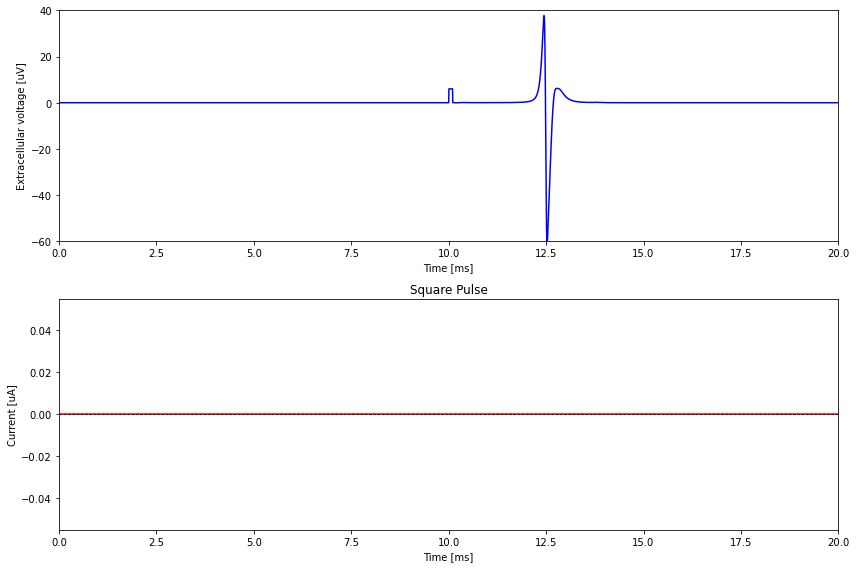

In [30]:
# Square pulse parameters
start_time = Stim['delay']  # ms
duration = Stim['dur']  # ms
height = Stim['amp']  # uA
x_square = np.array([0, start_time, start_time, start_time + duration, start_time + duration, 20])
y_square = np.array([0, 0, height, height, 0, 0])

# Create the plot
plt.figure(figsize=(12, 8))

# plot waveform
plt.subplot(2, 1, 1)
plt.plot(np.arange(0,Stim['stop']+Stim['dt'],Stim['dt']),recOut,color='blue',label='Extracellular voltage at distal axon')
plt.xlim(0,20)
plt.ylim(-60,40)
plt.xlabel("Time [ms]")
plt.ylabel("Extracellular voltage [uV]")
plt.grid(False)

# Plot square pulse
plt.subplot(2, 1, 2)
plt.plot(x_square, y_square, label="Stimulation pulse", color='red')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Square Pulse")
plt.xlabel("Time [ms]")
plt.ylabel("Current [uA]")
plt.xlim(0,20)
plt.grid(False)

plt.tight_layout()

# save the plot as a PNG
# plt.savefig('noSpike.png')
# plt.savefig('block_anodeBlockSpike_noDistalSpike.png')
plt.savefig('noBlock_distalSpike.png')

plt.show()


